# Probes_kinetic_properties_comparison: Robust fitting

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor

## Input experimental parameters

In [2]:
# -----------------------------
# Data (as provided)
# -----------------------------
dyes = ["Fluo-3", "Rhod-2", "CGr-2", "COr-5N"]
kd_values = np.array([0.74, 1.87, 1.94, 192.4], dtype=float)
tau_off_values = np.array([5.72, 7.85, 2.09, 0.155], dtype=float)

# Known Kd values for Fluo indicators (µM)
fluo_known_kds = {
    "Fluo-3": 0.39,
    "Fluo-4": 0.345,
    "Fluo-5F": 2.3,
    "Fluo-5N": 90,
    "Fluo-4FF": 9.7,
    "Fluo-8": 0.39,
    "Fluo-8H": 0.232,
    "Fluo-8L": 1.9,
    "Fluo-8FF": 10
}

## Robust linear regression in log-log space - Parameters

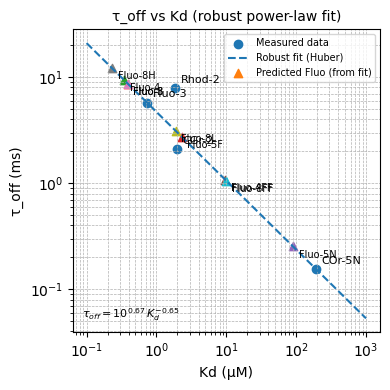

Robust fit parameters (log10 space):
  slope     = -0.648895
  intercept = 0.672541
Saved SVG to: robust_powerlaw_fit.svg


In [3]:
# -----------------------------
# Robust linear regression in log-log space
# log10(tau_off) = intercept + slope * log10(Kd)
# -----------------------------
log_kd = np.log10(kd_values).reshape(-1, 1)
log_tau = np.log10(tau_off_values)

robust_model = HuberRegressor(epsilon=1.35, alpha=0.0, max_iter=2000)
robust_model.fit(log_kd, log_tau)

slope = float(robust_model.coef_[0])
intercept = float(robust_model.intercept_)  # base-10 intercept in log space

# Predict over a Kd range
kd_pred_range = np.logspace(-1, 3, 400)
log_kd_pred = np.log10(kd_pred_range).reshape(-1, 1)
log_tau_pred = robust_model.predict(log_kd_pred)
tau_pred = 10 ** log_tau_pred

# Predict τ_off for Fluo indicators using the fitted power law
predicted_tau_fluo = {name: (10 ** intercept) * (kd ** slope) for name, kd in fluo_known_kds.items()}

# -----------------------------
# Plot (publication-sized 4x4 inches) + export SVG
# -----------------------------
plt.rcParams["svg.fonttype"] = "none"  # keep text as text in SVG (editable in Inkscape)

fig, ax = plt.subplots(figsize=(4, 4))

# Measured data
ax.scatter(kd_values, tau_off_values, marker="o", label="Measured data")
for dye, kd, tau in zip(dyes, kd_values, tau_off_values):
    ax.annotate(dye, (kd, tau), textcoords="offset points", xytext=(4, 4), ha="left", fontsize=8)

# Robust fitted model line
ax.plot(kd_pred_range, tau_pred, linestyle="--", label="Robust fit (Huber)")

# Fluo predictions (group label only once for legend)
first = True
for name, kd in fluo_known_kds.items():
    tau = predicted_tau_fluo[name]
    ax.scatter(kd, tau, marker="^", label="Predicted Fluo (from fit)" if first else "_nolegend_")
    first = False
    ax.annotate(name, (kd, tau), textcoords="offset points", xytext=(4, -8), ha="left", fontsize=7)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Kd (µM)")
ax.set_ylabel("τ_off (ms)")
ax.set_title("τ_off vs Kd (robust power-law fit)", fontsize=10)

# Equation annotation
eq_text = r"$\tau_{off}=10^{%.2f}\,K_d^{%.2f}$" % (intercept, slope)
ax.text(0.03, 0.03, eq_text, transform=ax.transAxes, fontsize=8, va="bottom", ha="left")

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=7, loc="best", frameon=True)
fig.tight_layout()

out_path = "robust_powerlaw_fit.svg"
fig.savefig(out_path, format="svg")
plt.show()

print("Robust fit parameters (log10 space):")
print(f"  slope     = {slope:.6f}")
print(f"  intercept = {intercept:.6f}")
print(f"Saved SVG to: {out_path}")